<a href="https://colab.research.google.com/github/Hasibur02/ASD-Detection-Deep-Learning/blob/main/ViT_B_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ==========================================================
# ASD Detection Using Deep Learning & Transfer Learning
# 01. IMPORTS
# ==========================================================

In [ ]:
# ============================
# IMPORTS
# ============================

import os
import random
import warnings

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torchvision.models import regnet_y_800mf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("=" * 60)
print("IMPORTS COMPLETED")
print("=" * 60)

print("PyTorch     :", torch.__version__)
print("TorchVision :", torchvision.__version__)
print("NumPy       :", np.__version__)

IMPORTS COMPLETED
PyTorch     : 2.11.0+cu128
TorchVision : 0.26.0+cu128
NumPy       : 2.0.2


# ==========================================================
# Device Configuration (Colab + Tesla T4 Optimized)
# ==========================================================

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(
        f"Memory: "
        f"{torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB"
    )

torch.backends.cudnn.benchmark = True

Using device: cuda
GPU: Tesla T4
Memory: 14.6 GB



# ==========================================================
#03. Dataset Setup
#==========================================================

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/AutismDataset"

train_dir = os.path.join(BASE_DIR, "train")
valid_dir = os.path.join(BASE_DIR, "valid")
test_dir = os.path.join(BASE_DIR, "test")

print("Dataset Path:", BASE_DIR)

Mounted at /content/drive
Dataset Path: /content/drive/MyDrive/AutismDataset


In [ ]:
def read_img(directory):

    image_paths = []
    labels = []

    for root, dirs, files in os.walk(directory):

        for image_file in sorted(files):

            if not image_file.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp", ".webp")
            ):
                continue

            image_path = os.path.join(root, image_file)

            folder_name = os.path.basename(root).lower()
            file_name = image_file.lower()

            if folder_name == "autistic":
                label = "Autistic"

            elif folder_name in ["non_autistic", "non-autistic"]:
                label = "Non_Autistic"

            elif file_name.startswith("autistic"):
                label = "Autistic"

            elif file_name.startswith("non_autistic"):
                label = "Non_Autistic"

            else:
                continue

            image_paths.append(image_path)
            labels.append(label)

    return pd.DataFrame({
        "image_path": image_paths,
        "label": labels
    })

In [ ]:
import pandas as pd
train_df = read_img(train_dir)
valid_df = read_img(valid_dir)
test_df = read_img(test_dir)

print("Training:", len(train_df))
print("Validation:", len(valid_df))
print("Testing:", len(test_df))

Training: 2542
Validation: 100
Testing: 300


# ==========================================================
# 04. DATASET STATISTICS
# ==========================================================

In [ ]:
datasets = {
    "Training": train_df,
    "Validation": valid_df,
    "Testing": test_df
}

print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)

# ----------------------------
# Dataset Size
# ----------------------------

for name, df in datasets.items():
    print(f"{name} Samples: {len(df):,}")

total_samples = sum(len(df) for df in datasets.values())

print(f"Total Samples: {total_samples:,}")


# ----------------------------
# Class Distribution
# ----------------------------

print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

for name, df in datasets.items():

    print(f"\n{name} Set:")
    print(df["label"].value_counts())

    print("\nPercentage:")
    print(
        (df["label"].value_counts(normalize=True) * 100)
        .round(2)
        .astype(str)
        + "%"
    )


# ----------------------------
# Missing Values
# ----------------------------

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

for name, df in datasets.items():

    print(f"\n{name}:")
    print(df.isnull().sum())


print("\n" + "=" * 60)
print("Dataset statistics completed.")
print("=" * 60)

DATASET STATISTICS
Training Samples: 2,542
Validation Samples: 100
Testing Samples: 300
Total Samples: 2,942

CLASS DISTRIBUTION

Training Set:
label
Non_Autistic    1272
Autistic        1270
Name: count, dtype: int64

Percentage:
label
Non_Autistic    50.04%
Autistic        49.96%
Name: proportion, dtype: object

Validation Set:
label
Autistic        50
Non_Autistic    50
Name: count, dtype: int64

Percentage:
label
Autistic        50.0%
Non_Autistic    50.0%
Name: proportion, dtype: object

Testing Set:
label
Autistic        150
Non_Autistic    150
Name: count, dtype: int64

Percentage:
label
Autistic        50.0%
Non_Autistic    50.0%
Name: proportion, dtype: object

MISSING VALUES

Training:
image_path    0
label         0
dtype: int64

Validation:
image_path    0
label         0
dtype: int64

Testing:
image_path    0
label         0
dtype: int64

Dataset statistics completed.


# ==========================================================
# 05. IMAGE TRANSFORMATIONS
# ==========================================================

In [ ]:

from torchvision import transforms
from torchvision.transforms import InterpolationMode


# ==========================================================
# CNN Training Transform
# ==========================================================

train_transform_cnn = transforms.Compose([

    transforms.RandomResizedCrop(
        size=224,
        scale=(0.8, 1.0),
        interpolation=InterpolationMode.BICUBIC
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(degrees=10),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),

    transforms.RandomErasing(
        p=0.2,
        scale=(0.02, 0.1)
    )
])


# ==========================================================
# ViT Training Transform
# ==========================================================

train_transform_vit = transforms.Compose([

    transforms.RandomResizedCrop(
        size=224,
        scale=(0.85, 1.0),
        interpolation=InterpolationMode.BICUBIC
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(degrees=5),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ==========================================================
# Validation / Test Transform
# ==========================================================

val_test_transform = transforms.Compose([

    transforms.Resize(
        (224, 224),
        interpolation=InterpolationMode.BICUBIC
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


print("Image transformations created successfully.")

Image transformations created successfully.


# ==========================================================
# 06. Hyperparameters
# ==========================================================

In [ ]:
# ==========================================================
# 06. HYPERPARAMETERS
# ==========================================================

# ----------------------------
# Training
# ----------------------------

NUM_EPOCHS = 25

LEARNING_RATE = 3e-5

WEIGHT_DECAY = 0.05

NUM_CLASSES = 2


# ----------------------------
# Batch Sizes
# ----------------------------

BATCH_SIZE = 16


# ----------------------------
# DataLoader
# ----------------------------

NUM_WORKERS = 2

PIN_MEMORY = torch.cuda.is_available()


# ----------------------------
# Early Stopping
# ----------------------------

PATIENCE = 7


# ----------------------------
# Reproducibility
# ----------------------------

RANDOM_SEED = 42


# ----------------------------
# Display
# ----------------------------

print("=" * 60)
print("HYPERPARAMETERS")
print("=" * 60)

print(f"Epochs          : {NUM_EPOCHS}")
print(f"Learning Rate   : {LEARNING_RATE}")
print(f"Weight Decay    : {WEIGHT_DECAY}")
print(f"Number of Classes: {NUM_CLASSES}")
print(f"Batch Size      : {BATCH_SIZE}")
print(f"Workers         : {NUM_WORKERS}")
print(f"Pin Memory      : {PIN_MEMORY}")
print(f"Early Stopping  : {PATIENCE}")
print(f"Random Seed     : {RANDOM_SEED}")

print("=" * 60)

HYPERPARAMETERS
Epochs          : 25
Learning Rate   : 3e-05
Weight Decay    : 0.05
Number of Classes: 2
Batch Size      : 16
Workers         : 2
Pin Memory      : True
Early Stopping  : 7
Random Seed     : 42


# ==========================================================
# 7. Dataset Class & DataLoaders
# ==========================================================

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from PIL import Image


# ==========================================================
# Hyperparameters
# ==========================================================

BATCH_SIZE = 16
NUM_WORKERS = 2

PIN_MEMORY = torch.cuda.is_available()


# ==========================================================
# CNN Validation / Test Transform
# ==========================================================

val_test_transform_cnn = transforms.Compose([

    transforms.Resize(
        (224, 224),
        interpolation=InterpolationMode.BICUBIC
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ==========================================================
# Autism Dataset Class
# ==========================================================

class AutismDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None,
        label_encoder=None,
        fit_label_encoder=False
    ):

        self.data = dataframe.reset_index(drop=True)

        self.transform = transform

        self.image_paths = self.data["image_path"].values


        # --------------------------------------------------
        # Label Encoding
        # --------------------------------------------------

        if label_encoder is None:

            self.label_encoder = LabelEncoder()

            if fit_label_encoder:

                self.labels = self.label_encoder.fit_transform(
                    self.data["label"]
                )

            else:

                raise ValueError(
                    "Set fit_label_encoder=True for training dataset"
                )

        else:

            self.label_encoder = label_encoder

            self.labels = self.label_encoder.transform(
                self.data["label"]
            )


    # ------------------------------------------------------
    # Number of Samples
    # ------------------------------------------------------

    def __len__(self):

        return len(self.data)


    # ------------------------------------------------------
    # Load One Image
    # ------------------------------------------------------

    def __getitem__(self, idx):

        image_path = self.image_paths[idx]

        try:

            image = Image.open(
                image_path
            ).convert("RGB")

        except Exception:

            print("Error loading:", image_path)

            image = Image.new(
                "RGB",
                (224, 224),
                "black"
            )


        # Apply transformation

        if self.transform:

            image = self.transform(image)


        # Label

        label = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )


        return image, label


    # ------------------------------------------------------
    # Label Encoder
    # ------------------------------------------------------

    def get_label_encoder(self):

        return self.label_encoder


    # ------------------------------------------------------
    # Class Names
    # ------------------------------------------------------

    def get_class_names(self):

        return self.label_encoder.classes_


# ==========================================================
# DataLoader Creation Function
# ==========================================================

def create_dataloaders(
    train_df,
    val_df,
    test_df,
    train_transform,
    val_test_transform,
    batch_size=16,
    num_workers=2
):


    # ======================================================
    # Training Dataset
    # ======================================================

    train_dataset = AutismDataset(

        train_df,

        transform=train_transform,

        fit_label_encoder=True
    )


    # Get Label Encoder

    label_encoder = train_dataset.get_label_encoder()


    # ======================================================
    # Validation Dataset
    # ======================================================

    val_dataset = AutismDataset(

        val_df,

        transform=val_test_transform,

        label_encoder=label_encoder
    )


    # ======================================================
    # Test Dataset
    # ======================================================

    test_dataset = AutismDataset(

        test_df,

        transform=val_test_transform,

        label_encoder=label_encoder
    )


    # ======================================================
    # DataLoader Arguments
    # ======================================================

    loader_args = {

        "batch_size": batch_size,

        "num_workers": num_workers,

        "pin_memory": PIN_MEMORY
    }


    if num_workers > 0:

        loader_args["persistent_workers"] = True

        loader_args["prefetch_factor"] = 2


    # ======================================================
    # Training DataLoader
    # ======================================================

    train_loader = DataLoader(

        train_dataset,

        shuffle=True,

        drop_last=True,

        **loader_args
    )


    # ======================================================
    # Validation DataLoader
    # ======================================================

    val_loader = DataLoader(

        val_dataset,

        shuffle=False,

        **loader_args
    )


    # ======================================================
    # Test DataLoader
    # ======================================================

    test_loader = DataLoader(

        test_dataset,

        shuffle=False,

        **loader_args
    )


    # ======================================================
    # Summary
    # ======================================================

    print("=" * 60)
    print("DATALOADER SUMMARY")
    print("=" * 60)

    print(
        f"Training Images   : {len(train_dataset):,}"
    )

    print(
        f"Validation Images : {len(val_dataset):,}"
    )

    print(
        f"Testing Images    : {len(test_dataset):,}"
    )

    print()

    print(
        f"Batch Size        : {batch_size}"
    )

    print(
        f"Workers           : {num_workers}"
    )

    print(
        f"Pin Memory        : {PIN_MEMORY}"
    )

    print()

    print("Classes:")
    print(label_encoder.classes_)

    print("=" * 60)


    return (
        train_loader,
        val_loader,
        test_loader,
        label_encoder
    )


# ==========================================================
# 7A. Create ViT-B/16 CNN DataLoaders
# ==========================================================

train_loader_cnn, val_loader_cnn, test_loader_cnn, label_encoder = create_dataloaders(

    train_df,
    valid_df,
    test_df,

    train_transform_cnn,
    val_test_transform_cnn,

    batch_size=16,
    num_workers=2
)


print("=" * 60)
print("ViT-B/16 DataLoaders Created")
print("=" * 60)

print(
    f"Training samples   : "
    f"{len(train_loader_cnn.dataset):,}"
)

print(
    f"Validation samples : "
    f"{len(val_loader_cnn.dataset):,}"
)

print(
    f"Test samples       : "
    f"{len(test_loader_cnn.dataset):,}"
)

print()

print(
    f"Training batches   : "
    f"{len(train_loader_cnn):,}"
)

print(
    f"Validation batches : "
    f"{len(val_loader_cnn):,}"
)

print(
    f"Test batches       : "
    f"{len(test_loader_cnn):,}"
)

print()

print(
    f"Classes            : "
    f"{list(label_encoder.classes_)}"
)

print(
    f"Number of classes  : "
    f"{len(label_encoder.classes_)}"
)


# ==========================================================
# 7B. Verify Batch
# =========================================================

images, labels = next(
    iter(train_loader_cnn)
)

print()
print("ViT-B/16 Batch Verification")
print("=" * 60)

print(
    f"Image batch shape : "
    f"{images.shape}"
)

print(
    f"Label shape       : "
    f"{labels.shape}"
)

print("=" * 60)


DATALOADER SUMMARY
Training Images   : 2,542
Validation Images : 100
Testing Images    : 300

Batch Size        : 16
Workers           : 2
Pin Memory        : True

Classes:
['Autistic' 'Non_Autistic']
ViT-B/16 DataLoaders Created
Training samples   : 2,542
Validation samples : 100
Test samples       : 300

Training batches   : 158
Validation batches : 7
Test batches       : 19

Classes            : ['Autistic', 'Non_Autistic']
Number of classes  : 2

ViT-B/16 Batch Verification
Image batch shape : torch.Size([16, 3, 224, 224])
Label shape       : torch.Size([16])


# ==========================================================
# 9. ModelTrainer Class Definition
# ==========================================================

In [ ]:
# ============================================================
# SECTION 8 — MODEL TRAINER
# ============================================================

import copy
import time

import torch
import torch.nn as nn

from tqdm.auto import tqdm
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.amp import autocast, GradScaler


class ModelTrainer:

    def __init__(
        self,
        model,
        train_loader,
        val_loader,
        device
    ):

        self.model = model.to(device)

        self.train_loader = train_loader
        self.val_loader = val_loader

        self.device = device

        # Training history
        self.train_losses = []
        self.val_losses = []

        self.train_accuracies = []
        self.val_accuracies = []


    # ========================================================
    # TRAIN MODEL
    # ========================================================

    def train_model(
        self,
        num_epochs=25,
        lr=3e-5,
        weight_decay=0.05,
        patience=7,
        model_name="RegNetY-800MF"
    ):

        # ----------------------------------------------------
        # Loss Function
        # ----------------------------------------------------

        criterion = nn.CrossEntropyLoss(
            label_smoothing=0.1
        )


        # ----------------------------------------------------
        # Optimizer
        # ----------------------------------------------------

        optimizer = AdamW(
            self.model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )


        # ----------------------------------------------------
        # Learning Rate Scheduler
        # ----------------------------------------------------

        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=num_epochs
        )


        # ----------------------------------------------------
        # Mixed Precision
        # ----------------------------------------------------

        scaler = GradScaler(
            "cuda",
            enabled=(self.device.type == "cuda")
        )


        # ----------------------------------------------------
        # Best Model Tracking
        # ----------------------------------------------------

        best_val_acc = 0.0

        best_weights = copy.deepcopy(
            self.model.state_dict()
        )

        patience_counter = 0


        # ----------------------------------------------------
        # Training Start
        # ----------------------------------------------------

        start_time = time.time()

        print("=" * 60)
        print(f"TRAINING: {model_name}")
        print("=" * 60)

        print(f"Epochs       : {num_epochs}")
        print(f"Learning Rate: {lr}")
        print(f"Weight Decay : {weight_decay}")
        print(f"Patience     : {patience}")
        print(f"Device       : {self.device}")

        print("=" * 60)


        # ====================================================
        # EPOCH LOOP
        # ====================================================

        for epoch in range(num_epochs):

            print(
                f"\nEpoch {epoch + 1}/{num_epochs}"
            )

            print("-" * 60)


            # =================================================
            # TRAINING PHASE
            # =================================================

            self.model.train()

            running_loss = 0.0
            correct = 0
            total = 0


            train_bar = tqdm(
                self.train_loader,
                desc="Train"
            )


            for images, labels in train_bar:

                images = images.to(
                    self.device,
                    non_blocking=True
                )

                labels = labels.to(
                    self.device,
                    non_blocking=True
                )


                # Clear gradients
                optimizer.zero_grad(
                    set_to_none=True
                )


                # Forward pass
                with autocast(
                    device_type=self.device.type,
                    enabled=(self.device.type == "cuda")
                ):

                    outputs = self.model(images)

                    loss = criterion(
                        outputs,
                        labels
                    )


                # Predictions
                predictions = torch.argmax(
                    outputs,
                    dim=1
                )


                # ------------------------------------------------
                # Backpropagation
                # ------------------------------------------------

                scaler.scale(loss).backward()


                # Gradient clipping
                scaler.unscale_(optimizer)

                torch.nn.utils.clip_grad_norm_(
                    self.model.parameters(),
                    max_norm=1.0
                )


                # Optimizer step
                scaler.step(optimizer)

                scaler.update()


                # ------------------------------------------------
                # Statistics
                # ------------------------------------------------

                batch_size = images.size(0)

                running_loss += (
                    loss.item() * batch_size
                )

                correct += (
                    predictions == labels
                ).sum().item()

                total += batch_size


                train_bar.set_postfix(
                    Loss=f"{running_loss / total:.4f}",
                    Acc=f"{correct / total:.4f}"
                )


            # Epoch training metrics

            train_loss = running_loss / total
            train_acc = correct / total


            self.train_losses.append(
                train_loss
            )

            self.train_accuracies.append(
                train_acc
            )


            print(
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_acc:.4f}"
            )


            # =================================================
            # VALIDATION PHASE
            # =================================================

            self.model.eval()

            running_loss = 0.0
            correct = 0
            total = 0


            with torch.no_grad():

                val_bar = tqdm(
                    self.val_loader,
                    desc="Val"
                )


                for images, labels in val_bar:

                    images = images.to(
                        self.device,
                        non_blocking=True
                    )

                    labels = labels.to(
                        self.device,
                        non_blocking=True
                    )


                    with autocast(
                        device_type=self.device.type,
                        enabled=(self.device.type == "cuda")
                    ):

                        outputs = self.model(images)

                        loss = criterion(
                            outputs,
                            labels
                        )


                    predictions = torch.argmax(
                        outputs,
                        dim=1
                    )


                    batch_size = images.size(0)

                    running_loss += (
                        loss.item() * batch_size
                    )

                    correct += (
                        predictions == labels
                    ).sum().item()

                    total += batch_size


                    val_bar.set_postfix(
                        Loss=f"{running_loss / total:.4f}",
                        Acc=f"{correct / total:.4f}"
                    )


            # Epoch validation metrics

            val_loss = running_loss / total
            val_acc = correct / total


            self.val_losses.append(
                val_loss
            )

            self.val_accuracies.append(
                val_acc
            )


            print(
                f"Val Loss: {val_loss:.4f} | "
                f"Val Acc: {val_acc:.4f}"
            )


            # =================================================
            # SAVE BEST MODEL
            # =================================================

            if val_acc > best_val_acc:

                best_val_acc = val_acc

                best_weights = copy.deepcopy(
                    self.model.state_dict()
                )

                patience_counter = 0


                torch.save(
                    {
                        "epoch": epoch + 1,
                        "model_state_dict":
                            self.model.state_dict(),
                        "optimizer_state_dict":
                            optimizer.state_dict(),
                        "scheduler_state_dict":
                            scheduler.state_dict(),
                        "best_val_acc":
                            best_val_acc
                    },
                    f"best_{model_name}.pth"
                )


                print(
                    f"✓ Best model saved "
                    f"(Val Acc: {best_val_acc:.4f})"
                )


            else:

                patience_counter += 1


            # =================================================
            # LEARNING RATE
            # =================================================

            scheduler.step()

            current_lr = scheduler.get_last_lr()[0]

            print(
                f"Learning Rate: {current_lr:.2e}"
            )


            # =================================================
            # EARLY STOPPING
            # =================================================

            if patience_counter >= patience:

                print(
                    "\n✓ Early stopping triggered."
                )

                break


        # ====================================================
        # RESTORE BEST MODEL
        # ====================================================

        self.model.load_state_dict(
            best_weights
        )


        elapsed = time.time() - start_time


        print("\n" + "=" * 60)
        print("TRAINING COMPLETED")
        print("=" * 60)

        print(
            f"Training Time          : "
            f"{elapsed // 60:.0f}m "
            f"{elapsed % 60:.0f}s"
        )

        print(
            f"Best Validation Accuracy: "
            f"{best_val_acc:.4f}"
        )

        print("=" * 60)


        return self.model

# ==========================================================
# 8. ViT-B/16 Model Definition
# ==========================================================

In [ ]:
# ============================================================
# 08. ViT-B/16 MODEL DEFINITION
# ============================================================

from torchvision.models import vit_b_16
import torch.nn as nn


def create_vit_b16_model(num_classes=2):

    model = vit_b_16(weights=None)

    # Custom classifier used during training
    # ViT-B/16 classification head input features = 768
    model.heads.head = nn.Linear(768, num_classes)

    return model


# ============================================================
# CREATE MODEL
# ============================================================

print("=" * 60)
print("CREATING ViT-B/16 MODEL")
print("=" * 60)

vit_model = create_vit_b16_model(
    num_classes=NUM_CLASSES
).to(device)


# ============================================================
# MODEL SUMMARY
# ============================================================

total_params = sum(
    p.numel()
    for p in vit_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in vit_model.parameters()
    if p.requires_grad
)

print(f"Model                : ViT-B/16")
print(f"Device               : {device}")
print(f"Total Parameters     : {total_params / 1e6:.2f} M")
print(f"Trainable Parameters : {trainable_params / 1e6:.2f} M")
print(f"Number of Classes    : {NUM_CLASSES}")

print("=" * 60)
print("✓ ViT-B/16 architecture is ready")

CREATING ViT-B/16 MODEL
Model                : ViT-B/16
Device               : cuda
Total Parameters     : 85.80 M
Trainable Parameters : 85.80 M
Number of Classes    : 2
✓ ViT-B/16 architecture is ready


In [ ]:
# ==========================================================
# Vision Transformer ViT-B/16
# ==========================================================

def create_vit_model(
    architecture="vit_b_16",
    num_classes=2,
    pretrained=True
):

    if architecture == "vit_b_16":

        weights = (
            ViT_B_16_Weights.DEFAULT
            if pretrained else None
        )

        model = vit_b_16(
            weights=weights
        )


    else:

        raise ValueError(
            "Only vit_b_16 supported"
        )


    in_features = model.heads.head.in_features


    model.heads.head = nn.Sequential(

        nn.Dropout(0.3),

        nn.Linear(
            in_features,
            num_classes
        )
    )


    return model

# ==========================================================
# 10. Train ViT-B/16 Model
# ==========================================================

In [ ]:
# ==========================================================
# ViT-B/16 Transforms (Colab Optimized)
# ==========================================================

from torchvision import transforms
from torchvision.transforms import InterpolationMode


# ----------------------------
# Training Transform
# ----------------------------

train_transform_vit = transforms.Compose([

    transforms.RandomResizedCrop(
        size=224,
        scale=(0.85, 1.0),
        interpolation=InterpolationMode.BICUBIC
    ),


    transforms.RandomHorizontalFlip(
        p=0.5
    ),


    transforms.RandomRotation(
        degrees=5
    ),


    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),


    transforms.ToTensor(),


    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])



# ----------------------------
# Validation / Test Transform
# ----------------------------

val_test_transform_vit = transforms.Compose([

    transforms.Resize(
        (224,224),
        interpolation=InterpolationMode.BICUBIC
    ),


    transforms.ToTensor(),


    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])



print("✅ ViT-B/16 transforms created")

✅ ViT-B/16 transforms created


In [ ]:
import copy
import time
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR

import torch
import torch.nn as nn

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


# ==========================================================
# Model Trainer Class
# ==========================================================

class ModelTrainer:

    def __init__(
        self,
        model,
        train_loader,
        val_loader,
        test_loader,
        device
    ):

        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.device = device

        self.train_losses = []
        self.val_losses = []

        self.train_accuracies = []
        self.val_accuracies = []

        self.model.to(device)



    def train_model(
        self,
        num_epochs=25,
        lr=1e-4,
        weight_decay=0.05,
        save_best=True,
        model_name="model"
    ):


        criterion = nn.CrossEntropyLoss(
            label_smoothing=0.1
        )


        optimizer = torch.optim.AdamW(
            self.model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )


        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=num_epochs
        )


        scaler = GradScaler(
            enabled=torch.cuda.is_available()
        )


        best_val_acc = 0.0

        best_weights = copy.deepcopy(
            self.model.state_dict()
        )


        patience = 7
        patience_counter = 0


        print(f"Starting training for {num_epochs} epochs...")
        print("-"*60)



        start_time = time.time()



        for epoch in range(num_epochs):


            print(
                f"\nEpoch {epoch+1}/{num_epochs}"
            )

            print("-"*60)



            for phase in ["train", "val"]:


                if phase == "train":

                    self.model.train()
                    loader = self.train_loader


                else:

                    self.model.eval()
                    loader = self.val_loader



                running_loss = 0.0
                correct = 0
                total = 0



                pbar = tqdm(
                    loader,
                    desc=phase.capitalize()
                )



                for images, labels in pbar:


                    images = images.to(
                        self.device,
                        non_blocking=True
                    )

                    labels = labels.to(
                        self.device,
                        non_blocking=True
                    )



                    optimizer.zero_grad(
                        set_to_none=True
                    )



                    with torch.set_grad_enabled(
                        phase=="train"
                    ):



                        with autocast(
                            enabled=torch.cuda.is_available()
                        ):


                            outputs = self.model(images)

                            loss = criterion(
                                outputs,
                                labels
                            )



                        _, preds = torch.max(
                            outputs,
                            1
                        )



                        if phase=="train":


                            scaler.scale(
                                loss
                            ).backward()



                            torch.nn.utils.clip_grad_norm_(
                                self.model.parameters(),
                                max_norm=1.0
                            )



                            scaler.step(
                                optimizer
                            )


                            scaler.update()



                    running_loss += (
                        loss.item()
                        * images.size(0)
                    )


                    correct += (
                        preds == labels
                    ).sum().item()


                    total += labels.size(0)



                    pbar.set_postfix(
                        Loss=f"{running_loss/total:.4f}",
                        Acc=f"{correct/total:.4f}"
                    )



                epoch_loss = running_loss / total

                epoch_acc = correct / total



                print(
                    f"{phase.capitalize()} "
                    f"Loss: {epoch_loss:.4f} "
                    f"Acc: {epoch_acc:.4f}"
                )



                if phase=="train":

                    self.train_losses.append(
                        epoch_loss
                    )

                    self.train_accuracies.append(
                        epoch_acc
                    )



                else:

                    self.val_losses.append(
                        epoch_loss
                    )

                    self.val_accuracies.append(
                        epoch_acc
                    )



                    if epoch_acc > best_val_acc:


                        best_val_acc = epoch_acc


                        best_weights = copy.deepcopy(
                            self.model.state_dict()
                        )


                        patience_counter = 0



                        if save_best:


                            torch.save(

                                {
                                "epoch": epoch,

                                "model_state_dict":
                                    self.model.state_dict(),

                                "optimizer_state_dict":
                                    optimizer.state_dict(),

                                "scheduler_state_dict":
                                    scheduler.state_dict(),

                                "best_val_acc":
                                    best_val_acc
                                },

                                f"best_{model_name}.pth"

                            )



                            print(
                                f"✓ Best model saved "
                                f"(Val Acc: {best_val_acc:.4f})"
                            )



                    else:

                        patience_counter += 1



            scheduler.step()


            print(
                f"Learning Rate: "
                f"{scheduler.get_last_lr()[0]:.2e}"
            )



            if patience_counter >= patience:

                print(
                    "Early stopping triggered"
                )

                break



        elapsed = time.time() - start_time



        self.model.load_state_dict(
            best_weights
        )


        print("\n"+"="*60)

        print(
            f"Training completed in "
            f"{elapsed//60:.0f}m "
            f"{elapsed%60:.0f}s"
        )

        print(
            f"Best Validation Accuracy: "
            f"{best_val_acc:.4f}"
        )

        print("="*60)



        return self.model


    def evaluate(self, data_loader):
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # Assuming same criterion as training

        with torch.no_grad():
            for images, labels in tqdm(data_loader, desc="Evaluating"):
                images = images.to(self.device, non_blocking=True)
                labels = labels.to(self.device, non_blocking=True)

                outputs = self.model(images)
                loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)

                running_loss += loss.item() * images.size(0)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        test_loss = running_loss / total
        test_acc = correct / total
        return test_loss, test_acc


# ==========================================================
# Create ViT-B/16 Model
# ==========================================================

print("Creating Vision Transformer (ViT-B/16) model...")


vit_b16_model = create_vit_model(
    architecture="vit_b_16",
    num_classes=2,
    pretrained=True
)



vit_b16_model = vit_b16_model.to(device)



# ==========================================================
# Parameter Summary
# ==========================================================

total_params = sum(
    p.numel()
    for p in vit_b16_model.parameters()
)


trainable_params = sum(
    p.numel()
    for p in vit_b16_model.parameters()
    if p.requires_grad
)



print("="*60)
print("ViT-B/16 Model Summary")
print("="*60)

print(f"Device              : {device}")

print(
    f"Total Parameters    : "
    f"{total_params/1e6:.2f} M"
)

print(
    f"Trainable Parameters: "
    f"{trainable_params/1e6:.2f} M"
)



# ==========================================================
# Create Trainer
# ==========================================================

vit_b16_trainer = ModelTrainer(
    model=vit_b16_model,
    train_loader=train_loader_vit,
    val_loader=val_loader_vit,
    test_loader=test_loader_vit,
    device=device
)



print("\n✅ ViT-B/16 Trainer Ready!")



# GPU Memory Check

if torch.cuda.is_available():

    print("\nGPU Memory Usage")

    print(
        f"Allocated: "
        f"{torch.cuda.memory_allocated()/1024**3:.2f} GB"
    )

    print(
        f"Reserved : "
        f"{torch.cuda.memory_reserved()/1024**3:.2f} GB"
    )

Creating Vision Transformer (ViT-B/16) model...
ViT-B/16 Model Summary
Device              : cpu
Total Parameters    : 85.80 M
Trainable Parameters: 85.80 M

✅ ViT-B/16 Trainer Ready!


In [ ]:
# ==========================================================
# Train ViT-B/16
# ==========================================================

print("="*60)
print("Training Vision Transformer (ViT-B/16)")
print("="*60)


# GPU memory before training
if torch.cuda.is_available():

    torch.cuda.empty_cache()

    print(
        f"GPU Memory Before Training: "
        f"{torch.cuda.memory_allocated()/1024**3:.2f} GB"
    )


# Start Training

trained_vit_b16 = vit_b16_trainer.train_model(

    num_epochs=25,

    # Fine-tuning learning rate
    lr=3e-5,

    weight_decay=0.05,

    save_best=True,

    model_name="ViT_B16_ASD"
)



print("\n" + "="*60)
print("✅ ViT-B/16 Training Completed!")
print("="*60)



# GPU memory after training

if torch.cuda.is_available():

    print(
        f"GPU Memory After Training: "
        f"{torch.cuda.memory_allocated()/1024**3:.2f} GB"
    )

Training Vision Transformer (ViT-B/16)
GPU Memory Before Training: 0.32 GB
Starting training for 25 epochs...
------------------------------------------------------------

Epoch 1/25
------------------------------------------------------------


Train: 100%|██████████| 158/158 [17:04<00:00,  6.49s/it, Acc=0.7330, Loss=0.5611]


Train Loss: 0.5611 Acc: 0.7330


Val: 100%|██████████| 7/7 [00:48<00:00,  6.91s/it, Acc=0.7700, Loss=0.5169]


Val Loss: 0.5169 Acc: 0.7700
✓ Best model saved (Val Acc: 0.7700)
Learning Rate: 2.99e-05

Epoch 2/25
------------------------------------------------------------


...

Val Loss: 0.5209 Acc: 0.8400
Learning Rate: 1.05e-06

Epoch 23/25
------------------------------------------------------------


Train: 100%|██████████| 158/158 [00:36<00:00,  4.32it/s, Acc=0.9960, Loss=0.2077]


Train Loss: 0.2077 Acc: 0.9960


Val: 100%|██████████| 7/7 [00:01<00:00,  5.93it/s, Acc=0.8500, Loss=0.5110]

Val Loss: 0.5110 Acc: 0.8500
Learning Rate: 4.71e-07
Early stopping triggered

Training completed in 33m 20s
Best Validation Accuracy: 0.8800

✅ ViT-B/16 Training Completed!
GPU Memory After Training: 0.34 GB


# ==========================================================
# 10. Evaluation ViT-B/16  Model
# ==========================================================

Checkpoint Found:
/content/best_ViT_B16_ASD.pth
✅ Best ViT-B/16 model loaded

ViT-B/16 Test Performance
Test Accuracy : 0.8733
Test Samples  : 300

Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

    Autistic       0.84      0.92      0.88       150
Non_Autistic       0.91      0.83      0.87       150

    accuracy                           0.87       300
   macro avg       0.88      0.87      0.87       300
weighted avg       0.88      0.87      0.87       300


Confusion Matrix
------------------------------------------------------------
[[138  12]
 [ 26 124]]


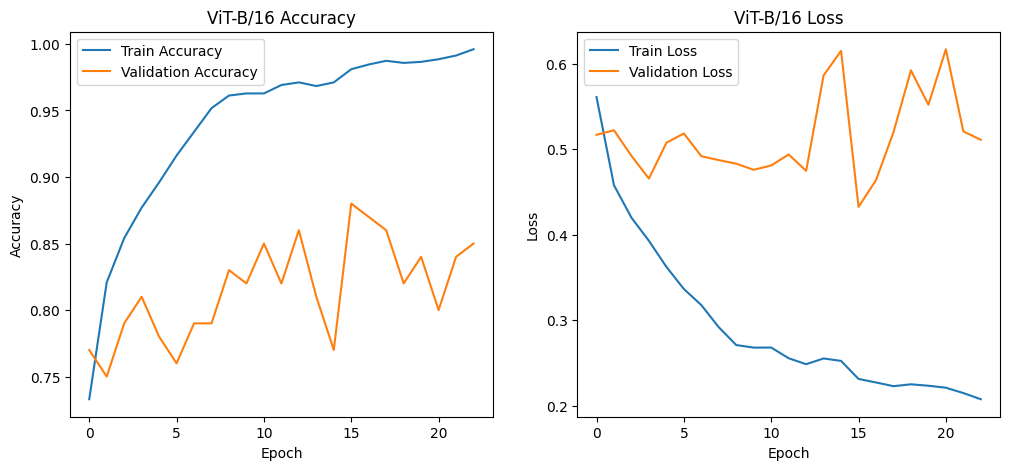

In [ ]:
# ==========================================================
# ViT-B/16 Final Evaluation (Auto Checkpoint Finder)
# ==========================================================

import os
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)


# ----------------------------------------------------------
# 1. Find Saved Model Checkpoint Automatically
# ----------------------------------------------------------

checkpoint_path = None


for root, dirs, files in os.walk("/content"):

    for file in files:

        if file.endswith(".pth") or file.endswith(".pt"):

            checkpoint_path = os.path.join(root, file)
            break

    if checkpoint_path:
        break



if checkpoint_path is None:

    raise FileNotFoundError(
        "❌ No .pth/.pt model checkpoint found"
    )


print("="*60)
print("Checkpoint Found:")
print(checkpoint_path)
print("="*60)



# ----------------------------------------------------------
# 2. Load Best ViT-B/16 Model
# ----------------------------------------------------------

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)


# Handle both saved model formats

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:

    vit_b16_trainer.model.load_state_dict(
        checkpoint["model_state_dict"]
    )

else:

    vit_b16_trainer.model.load_state_dict(
        checkpoint
    )


vit_b16_trainer.model.eval()


print("✅ Best ViT-B/16 model loaded")



# ----------------------------------------------------------
# 3. Test Evaluation
# ----------------------------------------------------------

vit_b16_preds = []
vit_b16_labels = []

correct = 0
total = 0



with torch.no_grad():

    for images, labels in test_loader_vit:


        images = images.to(device)
        labels = labels.to(device)


        outputs = vit_b16_trainer.model(images)

        _, preds = torch.max(outputs, 1)


        correct += (
            preds == labels
        ).sum().item()


        total += labels.size(0)


        vit_b16_preds.extend(
            preds.cpu().numpy()
        )

        vit_b16_labels.extend(
            labels.cpu().numpy()
        )



vit_b16_test_acc = correct / total



print("\n" + "="*60)
print("ViT-B/16 Test Performance")
print("="*60)

print(
    f"Test Accuracy : {vit_b16_test_acc:.4f}"
)

print(
    f"Test Samples  : {total}"
)

print("="*60)



# ----------------------------------------------------------
# 4. Classification Report
# ----------------------------------------------------------

print("\nClassification Report")
print("-"*60)


print(
    classification_report(
        vit_b16_labels,
        vit_b16_preds,
        target_names=[
            "Autistic",
            "Non_Autistic"
        ]
    )
)



# ----------------------------------------------------------
# 5. Confusion Matrix
# ----------------------------------------------------------

print("\nConfusion Matrix")
print("-"*60)


cm = confusion_matrix(
    vit_b16_labels,
    vit_b16_preds
)

print(cm)



# ----------------------------------------------------------
# 6. Plot Training History
# ----------------------------------------------------------


history_available = (
    hasattr(vit_b16_trainer,"train_accuracies")
    and
    hasattr(vit_b16_trainer,"val_accuracies")
)


if history_available:


    plt.figure(figsize=(12,5))


    # Accuracy Plot
    plt.subplot(1,2,1)

    plt.plot(
        vit_b16_trainer.train_accuracies,
        label="Train Accuracy"
    )

    plt.plot(
        vit_b16_trainer.val_accuracies,
        label="Validation Accuracy"
    )


    plt.title("ViT-B/16 Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()



    # Loss Plot
    plt.subplot(1,2,2)

    plt.plot(
        vit_b16_trainer.train_losses,
        label="Train Loss"
    )

    plt.plot(
        vit_b16_trainer.val_losses,
        label="Validation Loss"
    )


    plt.title("ViT-B/16 Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()


    plt.show()


else:

    print(
        "⚠ Training history not found in trainer object"
    )


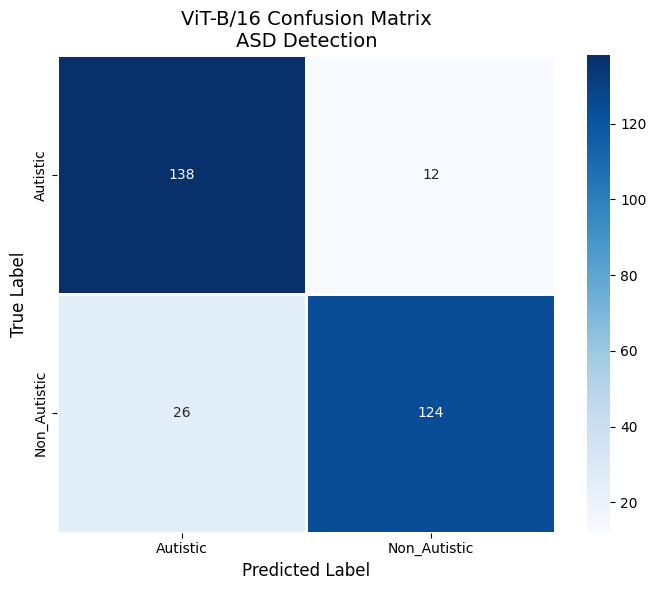

In [ ]:
# ==========================================================
# ViT-B/16 Confusion Matrix Visualization
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix


# Create confusion matrix

cm = confusion_matrix(
    vit_b16_labels,
    vit_b16_preds
)


# Plot

plt.figure(figsize=(7,6))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Autistic",
        "Non_Autistic"
    ],
    yticklabels=[
        "Autistic",
        "Non_Autistic"
    ],
    linewidths=1,
    cbar=True
)


plt.title(
    "ViT-B/16 Confusion Matrix\nASD Detection",
    fontsize=14
)

plt.xlabel(
    "Predicted Label",
    fontsize=12
)

plt.ylabel(
    "True Label",
    fontsize=12
)


plt.tight_layout()

plt.show()

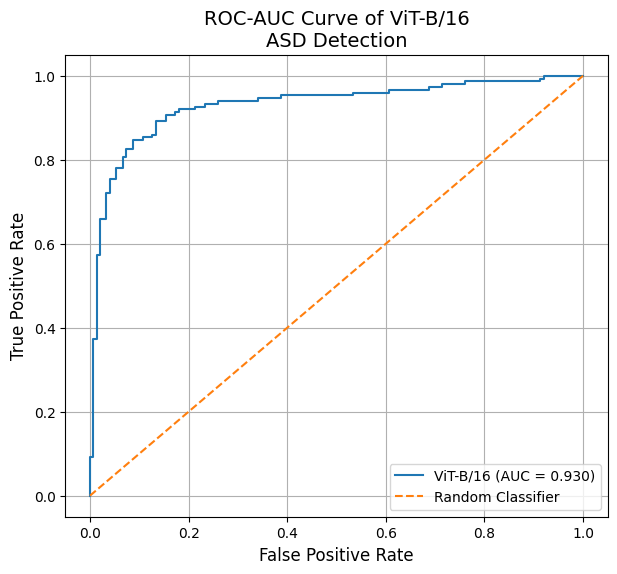

ROC-AUC Score: 0.9298


In [ ]:
# ==========================================================
# ViT-B/16 ROC-AUC Curve Visualization
# ==========================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    roc_auc_score
)


# ----------------------------------------------------------
# Collect prediction probabilities
# ----------------------------------------------------------

vit_b16_probs = []

vit_b16_model.eval()

with torch.no_grad():

    for images, labels in test_loader_vit:

        images = images.to(device)

        outputs = vit_b16_model(images)

        # Convert logits to probability
        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        # Probability of ASD class
        asd_probability = probabilities[:,1]

        vit_b16_probs.extend(
            asd_probability.cpu().numpy()
        )


# ----------------------------------------------------------
# Calculate ROC curve
# ----------------------------------------------------------

fpr, tpr, thresholds = roc_curve(
    vit_b16_labels,
    vit_b16_probs
)


# Calculate AUC

roc_auc = auc(
    fpr,
    tpr
)


# ----------------------------------------------------------
# Plot ROC Curve
# ----------------------------------------------------------

plt.figure(figsize=(7,6))


plt.plot(
    fpr,
    tpr,
    label=f"ViT-B/16 (AUC = {roc_auc:.3f})"
)


# Random classifier line

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)


plt.title(
    "ROC-AUC Curve of ViT-B/16\nASD Detection",
    fontsize=14
)


plt.xlabel(
    "False Positive Rate",
    fontsize=12
)


plt.ylabel(
    "True Positive Rate",
    fontsize=12
)


plt.legend(
    loc="lower right"
)


plt.grid(True)


plt.show()


print(
    f"ROC-AUC Score: {roc_auc:.4f}"
)


In [ ]:
# ==========================================================
# ViT-B/16 Classification Report
# ASD Detection
# ==========================================================

from sklearn.metrics import classification_report


# Generate classification report

report = classification_report(
    vit_b16_labels,
    vit_b16_preds,
    target_names=[
        "Autistic",
        "Non-Autistic"
    ],
    digits=4
)


print(
    "ViT-B/16 Classification Report\n"
)

print(report)

ViT-B/16 Classification Report

              precision    recall  f1-score   support

    Autistic     0.8415    0.9200    0.8790       150
Non-Autistic     0.9118    0.8267    0.8671       150

    accuracy                         0.8733       300
   macro avg     0.8766    0.8733    0.8731       300
weighted avg     0.8766    0.8733    0.8731       300

